# Trying some Code from the Kaggle tutorial

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from pathlib import Path

def find_repo_root(marker="README.md"):
    """Walk up from current path to find the repo root containing `marker`."""
    current = Path().resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find repo root with marker '{marker}'")

# Find repo root using a known file at the root
repo_root = find_repo_root("README.md")

# Path to the CSV file
GFOC_path = repo_root / Path('Dataset/Dataset_MSc/GFOC_RDCDFI.csv')

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay', 'se_orbital_decay']

# Try to load with limited columns first
try:
    GFOC_data = pd.read_csv(GFOC_path, usecols=columns_needed, low_memory=True)
    print(f"Successfully loaded data with shape: {GFOC_data.shape}")
except MemoryError:
    print("Still running out of memory. Loading in chunks...")
    # If still out of memory, load in chunks
    chunk_list = []
    chunksize = 50000  # Adjust this number based on your available memory
    
    for chunk in pd.read_csv(GFOC_path, usecols=columns_needed, chunksize=chunksize, low_memory=True):
        chunk_list.append(chunk)
    
    GFOC_data = pd.concat(chunk_list, ignore_index=True)
    print(f"Successfully loaded data in chunks with shape: {GFOC_data.shape}")



Successfully loaded data with shape: (1486079, 3)


# Data Plot

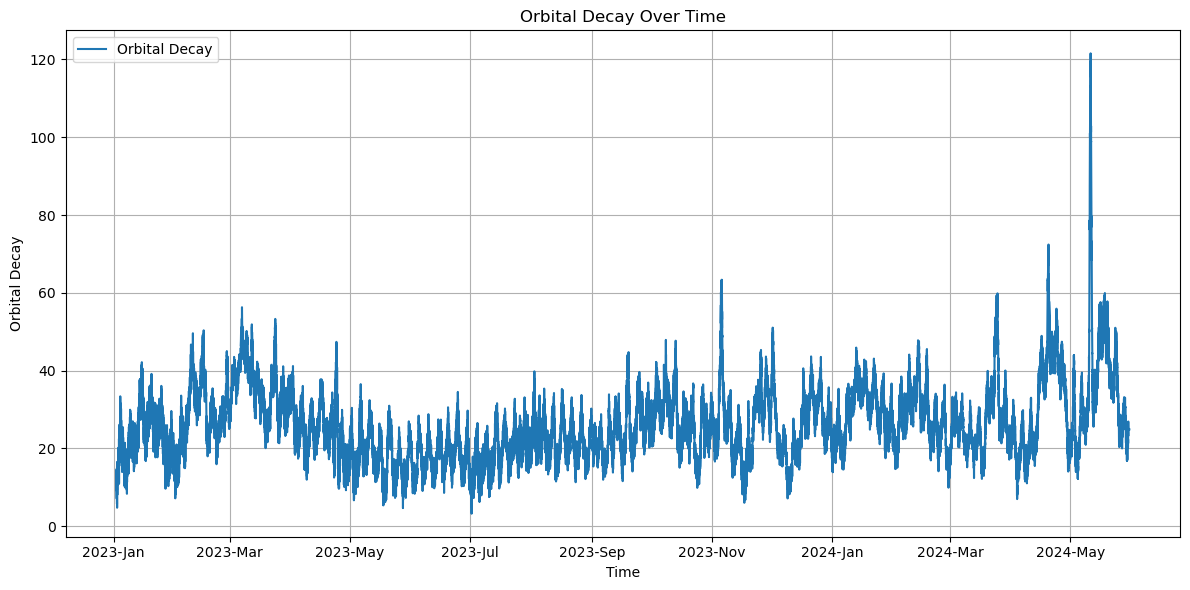

In [4]:
import matplotlib.dates as mdates
import numpy as np

# =========================== Input ===================================
# start_date = '2023-01-01 00:00:00'
# end_date = '2024-04-15 00:00:00'
start_date = GFOC_data['time'].values[0]
end_date = GFOC_data['time'].values[-4322] #removed gap by ignoring the last 4321 values

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 2  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

# plt.style.use('dark_background')
plt.style.use('default')

# Helper function for tick formatting
def format_ticks(ax, tick_interval, tick_step):
    if tick_interval == 'monthly':
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=tick_step))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))                         
    elif tick_interval == 'daily':
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=tick_step))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    elif tick_interval == 'hourly':
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_step))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    ax.tick_params(axis='x', rotation=0)
# =====================================================================


# GFOC_data = GFOC_data[(GFOC_data['time'] >= start_date) & (GFOC_data['time'] <= end_date)]
# GFOC_time = GFOC_data['time']

GFOC_subset = GFOC_data[(GFOC_data['time'] >= start_date) & (GFOC_data['time'] <= end_date)]
GFOC_time = GFOC_subset['time']

# time conversion
GFOC_time = pd.to_datetime(GFOC_time, format='%Y-%m-%d %H:%M:%S')

fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(GFOC_time, GFOC_data['orbital_decay'], label='Orbital Decay')
ax.plot(GFOC_time, GFOC_subset['orbital_decay'], label='Orbital Decay')
format_ticks(ax, tick_interval, tick_step)
ax.set_xlabel('Time')
ax.set_ylabel('Orbital Decay')
ax.set_title('Orbital Decay Over Time')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Lag feature

[None,
 Text(0, 0.5, 'Orbital Decay'),
 Text(0.5, 0, 'lag_1'),
 Text(0.5, 1.0, 'Lag Plot of Orbital Decay')]

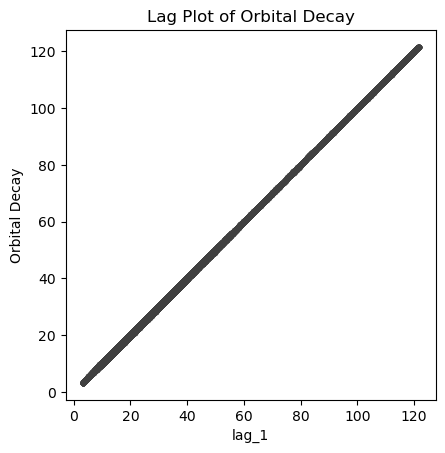

In [10]:
lag_1 = GFOC_data['orbital_decay'].shift(1)
GFOC_data['lag_1'] = lag_1

X = GFOC_data.loc[:, ['lag_1']].dropna()
y = GFOC_data.loc[:, 'orbital_decay']
y, X = y.align(X, join='inner')

fig, ax = plt.subplots()
ax.plot(X['lag_1'], y, '.', color='0.25')
# ax.plot(X['lag_1'], y_pred)
ax.set(aspect='equal', ylabel='Orbital Decay', xlabel='lag_1', title='Lag Plot of Orbital Decay')

There seems to be a very strong correlation between following points. Is this useful though?